In [30]:
import scipy.stats as stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

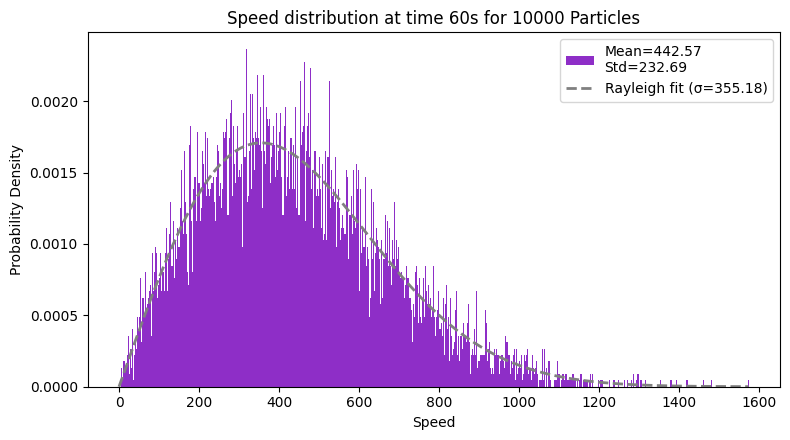

In [32]:
numOfparticles=10000
numspeedDF=pd.read_csv(r"2000L,10000N,r0.7 1\Data\speeds.txt")
numspeed=numspeedDF.to_numpy()
binNumber=700
time=60
length=2000
radius=0.7

numspeed = numspeed.flatten()
plt.figure(figsize=(8,4.5))



plt.hist(
    numspeed,
    bins=binNumber,
    density=True,
    color="#8E2EC7",
    label=f"Mean={np.mean(numspeed):.2f}\nStd={np.std(numspeed):.2f}"
)

sigma = np.std(numspeed) / np.sqrt((4 - np.pi) / 2)

x = np.linspace(0, numspeed.max(), 2000)
pdf = stats.rayleigh(scale=sigma).pdf(x)

plt.plot(x, pdf, linestyle="--", color="grey", linewidth=2,
         label=f"Rayleigh fit (σ={sigma:.2f})")

plt.title(f"Speed distribution at time {time}s for {numOfparticles} Particles")
plt.xlabel("Speed")
plt.ylabel("Probability Density")
plt.legend()
plt.tight_layout()
os.makedirs("Graphs",exist_ok=True)
plt.savefig(f"Graphs/{numOfparticles}N{time}S{length}{radius}R.png")
plt.show()

